In [1]:
import os
import sys

# Add the `app` folder to sys.path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

In [2]:
from langchain.agents import create_agent
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Annotated
from core.modelConfig import ModelConfigManager
from langchain_core.tools import tool 
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from dotenv import load_dotenv
load_dotenv()
from services.lease_extractor import extract_from_pdf
import json
import requests
from schemas.property_manager import PropertyManager
from agents.lease.talk2lease import TalkToLeaseRAG

In [3]:
llm = ModelConfigManager('gpt-4o-mini', 0, 3).model()

In [4]:
class AgentState(TypedDict):
    user_query: str
    answer: str
    user_id: str
    extracted_data : dict
    messages: list
    intent: str
    lease_id: str
    

In [5]:
@tool
def extract_lease_details(pdf_path: str) -> str:
    """Extracts lease details from a PDF file"""
    result = extract_from_pdf(pdf_path)
    return json.dumps(result, ensure_ascii=False, indent=2)

@tool
def invite_tenant(phone_number: str):
    "Send tenant an invite to onboard onto their apartment"
    url = "https://graph.facebook.com/v22.0/1038342679352534/messages"
    access_token = "EAFxBVnL8gzYBQ8uZA34o6FIni23cQTdI9ZCv0lrdSw6rLhqXZAZAKcEoZBucEjzlOZAZATBdgWHNpWYH8r0CiiqPO1s7M8L3OrZAUsVV5CtNPXAEFsu10B67d9E0hKYVq2K3gvzWZCZCgddgZAqZAXE7bRZA7bmbJMDX6vrPSZA434OkevGwV2pAVi8vkWDLD7ooStvvraLASLpfkaYNwVYQHfyVW24wnMA9zO9RevtXsrEKeTjCsGPWA1kzq5PXSIlPa0XQHoKroL1vSka5VMZCBiQI9qlnpeY"
    headers = {
        "Authorization": f"Bearer {access_token}",
        "Content-Type": "application/json"
    }
    payload = {
        "messaging_product": "whatsapp",
        "to": phone_number,
        "type": "template",
        "template": {
            "name": "hello_world",
            "language": {"code": "en_US"}
        }
    }
    response = requests.post(url, headers=headers, json=payload)
    return response.json()


@tool
def create_property(
    owner_id: int,
    landlord_name: str,
    property_name: str,
    address_line1: str | None = None,
    city: str | None = None,
    state: str | None = None,
    postal_code: str | None = None,
) -> dict:
    """Create a property record in the database for the landlord"""
    created = PropertyManager().add_property(
        owner_id=owner_id,
        landlord_name=landlord_name,
        name=property_name,
        address_line1=address_line1,
        city=city,
        state=state,
        postal_code=postal_code,
    )

    return {
        "property_id": created.get("id"),
        "property": created,
        "status": "success",
    }
    
# --- Define Node ---
def onboarding_agent(state: AgentState) -> dict:
    """Run onboarding agent and return messages + final answer."""
    agent = create_agent(
        llm,
        [extract_lease_details, invite_tenant, create_property],
        system_prompt=(
            "You are an onboarding agent with the helpful assistant with access to tools to carry out the tasks. "
            "1. Extract Lease Details 2. Invite Tenant, 3. Creating and Storing records for uploaded lease documents."
        ),
    )
    result = agent.invoke({"messages": state["user_query"]})
    messages = result.get("messages", [])
    answer = messages[-1].content if messages else ""
    return {"messages": messages, "answer": answer}

In [7]:
@tool
def store_lease():
    "DocString"
    pass

@tool 
def inquire_lease(state: AgentState) -> dict:
    """Inquire about a lease"""
    rag = TalkToLeaseRAG(
        model_name="gpt-4o-mini",
        temperature=0,
        max_retries=3,
    )
    query = state["user_query"]
    lease_id = state["lease_id"]
    answer = rag.answer_question(query, lease_id)
    return {"answer": answer, "lease_id": lease_id}

def lease_agent(state: AgentState) -> dict:
    """Run lease agent and return messages + final answer."""
    agent = create_agent(
        llm,
        [extract_lease_details, invite_tenant, create_property],
        system_prompt=(
            "You are a lease agent with access to tools to carry out lease-related tasks. "
            "1. Extract Lease Details 2. Invite Tenant, 3. Creating and Storing records for uploaded lease documents."
        ),
    )
    result = agent.invoke({"messages": state["user_query"]})
    messages = result.get("messages", [])
    answer = messages[-1].content if messages else ""
    return {"messages": messages, "answer": answer}

In [8]:
def reminder_agent(state: AgentState) -> dict:
    pass 

In [9]:
def payments_agent(state: AgentState) -> dict:
    pass 

In [13]:
def insights_agent(state: AgentState) -> dict:
    pass

In [14]:
def router_node(state: AgentState) -> AgentState:
    """Route based on the user's intent derived from the query.

    Uses the LLM to classify the incoming `user_query` into one of two
    intents:
    - "lease"       → handled by `lease_agent`
    - "onboarding"  → handled by `onboarding_agent`

    It writes the chosen intent into the graph state so that
    `route_by_intent` can send the flow to the right node.
    """
    user_query = state.get("user_query", "")

    if not user_query:
        # Fallback: if no query, keep existing intent or default
        intent = state.get("intent", "onboarding")
    else:
        classification_prompt = (
            "You are an intent classifier for a property management assistant.\n"
            "Decide whether the user query is about lease-related tasks "
            "(like extracting details, signing, stamping, or storing a lease) "
            "or about general onboarding tasks (like inviting tenants, "
            "creating a property, or account setup).\n"
            "Respond with exactly one word: 'lease' or 'onboarding'.\n\n"
            f"User query: {user_query}"
        )

        response = llm.invoke([HumanMessage(content=classification_prompt)])
        intent = getattr(response, "content", "").strip().lower()

        if intent not in ("lease", "onboarding"):
            intent = "onboarding"

    return {"intent": intent}


def route_by_intent(state: AgentState):
    return state["intent"]

In [15]:
# --- Define Graph ---
workflow = StateGraph(AgentState)

workflow.add_node("lease_agent", lease_agent)
workflow.add_node("onboard_agent", onboarding_agent)
workflow.add_node("router", router_node)
workflow.add_node("reminder_agent", reminder_agent)
workflow.add_node("payments_agent", payments_agent)
workflow.add_node("insights_agent", insights_agent)

workflow.set_entry_point("router")
workflow.add_conditional_edges(
    "router",
    route_by_intent,
    {
        "lease" : "lease_agent",
        "onboarding": "onboard_agent",
        "reminder": "reminder_agent",
        "payments": "payments_agent",
        "insights": "insights_agent"
    },
)
workflow.add_edge("lease_agent", END)
workflow.add_edge("onboard_agent", END)
workflow.add_edge("reminder_agent", END)
workflow.add_edge("payments_agent", END)  
workflow.add_edge("insights_agent", END)
app = workflow.compile()

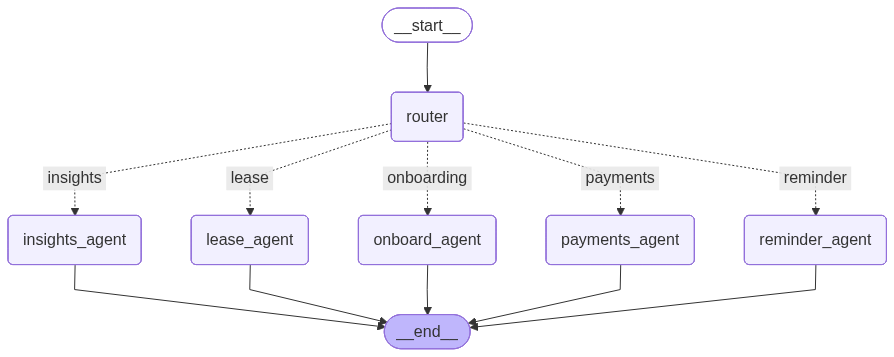

In [16]:
from IPython.display import Image, display
Image(app.get_graph().draw_mermaid_png())

In [ ]:
# # --- Run Graph with streaming to inspect tool calls ---
# for event in app.stream({
#     "user_query": "Please onboard the tenant mentioned in the lease /Users/anshagarwal/Developer/KirayaEase/data/sample_rent_agreement.pdf. Phone is 16088867232"
# }):
#     print("\n--- Stream event ---")
#     for key, value in event.items():
#         print(key, ":", value)

# # If you still want the final answer as before, you can also do:
# # final_state = app.invoke({
# #     "user_query": "Please onboard the tenant mentioned in the lease /Users/anshagarwal/Developer/KirayaEase/data/sample_rent_agreement.pdf"
# # })
# # print("\nFinal answer:\n", final_state["answer"])


--- Stream event ---
router : {'intent': 'onboarding'}

--- Stream event ---
onboard_agent : {'answer': 'The tenant has been invited successfully. However, there was an authentication error while trying to create the property record. \n\nThe property record has been created successfully with the following details:\n- **Landlord Name:** Ravi Sharma\n- **Property Name:** 123 MainStreet, Hoboken, NJ\n- **Address Line 1:** 123 MainStreet\n- **City:** Hoboken\n- **State:** NJ\n\nIf you need any further assistance or actions, please let me know!'}


In [21]:
def _print_tool_details(msg):
    # Tool calls from AI messages (function calling)
    tool_calls = getattr(msg, "tool_calls", None)
    if not tool_calls:
        tool_calls = getattr(msg, "additional_kwargs", {}).get("tool_calls")

    if tool_calls:
        print("  tool_calls:")
        for tc in tool_calls:
            if isinstance(tc, dict):
                tc_id = tc.get("id")
                name = tc.get("name")
                args = tc.get("args")
            else:
                tc_id = getattr(tc, "id", None)
                name = getattr(tc, "name", None)
                args = getattr(tc, "args", None)
            print(f"    - id={tc_id} name={name} args={args}")

    # Tool results are ToolMessage instances
    if isinstance(msg, ToolMessage):
        print(f"  tool_result: name={msg.name} tool_call_id={msg.tool_call_id}")


# --- Run Graph with streaming to inspect tool calls ---
for event in app.stream({
    "user_query": "Please onboard the tenant mentioned in the lease /Users/anshagarwal/Developer/KirayaEase/data/sample_rent_agreement.pdf. Phone is 16088867232"
}):
    print("\n================ STREAM EVENT ================")
    for node_name, state in event.items():
        print(f"\n--- Node: {node_name} ---")

        if "intent" in state:
            print("intent:", state["intent"])

        messages = state.get("messages") or []
        if messages:
            print("messages (last 8):")
            for m in messages[-8:]:
                m_type = getattr(m, "type", m.__class__.__name__)
                content = getattr(m, "content", "")
                print(f"- [{m_type}] {content}")
                _print_tool_details(m)

        if "answer" in state:
            print("\nanswer:\n", state["answer"])


================ STREAM EVENT ================

--- Node: router ---
intent: onboarding

================ STREAM EVENT ================

--- Node: onboard_agent ---
messages (last 8):
- [human] Please onboard the tenant mentioned in the lease /Users/anshagarwal/Developer/KirayaEase/data/sample_rent_agreement.pdf. Phone is 16088867232
- [ai] 
  tool_calls:
    - id=call_pUj1C5uPm6WQoxYM1I3uc11i name=extract_lease_details args={'pdf_path': '/Users/anshagarwal/Developer/KirayaEase/data/sample_rent_agreement.pdf'}
- [tool] {
  "landlord_name": "Ravi Sharma",
  "landlord_phone": null,
  "landlord_email": null,
  "landlord_address": null,
  "property_address": "123 MainStreet, Hoboken, NJ",
  "property_pincode": null,
  "start_date": "2026-03-01",
  "end_date": "2027-02-28",
  "tenant_name": "Ansh Agarwal",
  "tenant_address": null,
  "tenant_city": null,
  "tenant_state": null,
  "tenant_pincode": null,
  "tenant_phone": null,
  "aadhar": null,
  "pan": null,
  "rent_amount_inr": "2500"
}
